In [ ]:
"""
查看推理时冗余肽段数目
"""

In [153]:
import os

# pfind_res_dir = "D:/pFindWorkspace/Astral/new/top50-complete/result/restricted-0627/"
pfind_res_dir = "D:/pFindWorkspace/normal/Gygi_2015_NBT/restrict-new/result/restricted-0628/"
pfind_qryres_paths = [os.path.join(pfind_res_dir,path) for path in os.listdir(pfind_res_dir) if path.endswith(".sa")]


infos1 = list()  # 每个文件的肽段总数、unique肽段数目
infos2 = list()  # 累积肽段总数、unique肽段数目
total = 0  # 肽段总数
peptides = set()
for pfind_qryres_path in pfind_qryres_paths:
    total_local = 0  # 该文件肽段总数
    peptides_local = set()
    print(pfind_qryres_path)
    f = open(pfind_qryres_path,"r")
    next(f,None)
    rank = 0
    for i,line in enumerate(f):
        items = line.split("\t")
        if len(items) <= 3:
            # rank = 0
            continue
        # elif rank>=3:
        #     continue
        # rank += 1
        total_local += 1
        seq = items[1]
        mod_num = int(items[6])
        mod = ""
        for i in range(mod_num):
            mod += f"{items[7+2*i]},{items[8+2*i]}"
        peptide = seq + "\t" + mod  # seq+mod
        peptides_local.add(peptide)
    f.close()

    total += total_local
    peptides.update(peptides_local)
    infos1.append([total_local, len(peptides_local)])
    infos2.append([total, len(peptides)])
    # break

print(infos1)
print(infos2)

D:/pFindWorkspace/normal/Gygi_2015_NBT/restrict-new/result/restricted-0628/restrict-new.F1.L1.sa
D:/pFindWorkspace/normal/Gygi_2015_NBT/restrict-new/result/restricted-0628/restrict-new.F10.L1.sa
D:/pFindWorkspace/normal/Gygi_2015_NBT/restrict-new/result/restricted-0628/restrict-new.F11.L1.sa
D:/pFindWorkspace/normal/Gygi_2015_NBT/restrict-new/result/restricted-0628/restrict-new.F12.L1.sa
D:/pFindWorkspace/normal/Gygi_2015_NBT/restrict-new/result/restricted-0628/restrict-new.F13.L1.sa
D:/pFindWorkspace/normal/Gygi_2015_NBT/restrict-new/result/restricted-0628/restrict-new.F14.L1.sa
D:/pFindWorkspace/normal/Gygi_2015_NBT/restrict-new/result/restricted-0628/restrict-new.F15.L1.sa
D:/pFindWorkspace/normal/Gygi_2015_NBT/restrict-new/result/restricted-0628/restrict-new.F16.L1.sa
D:/pFindWorkspace/normal/Gygi_2015_NBT/restrict-new/result/restricted-0628/restrict-new.F17.L1.sa
D:/pFindWorkspace/normal/Gygi_2015_NBT/restrict-new/result/restricted-0628/restrict-new.F18.L1.sa
D:/pFindWorkspace/nor

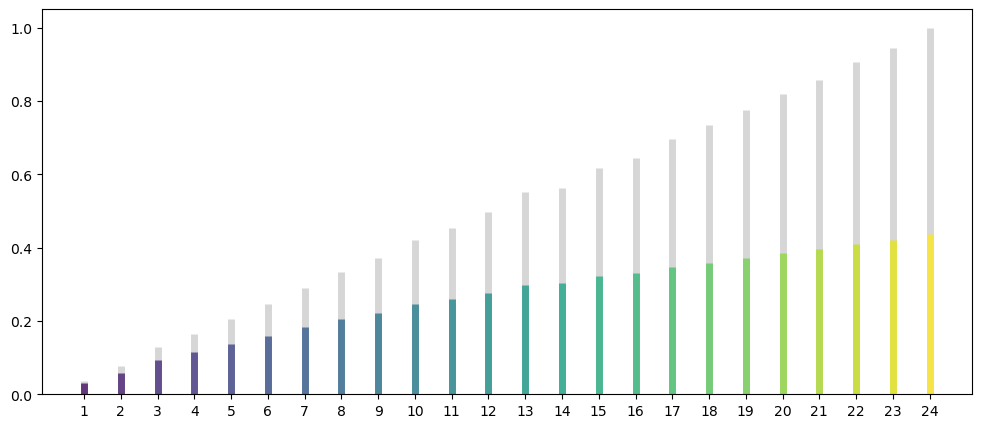

In [155]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))  # 设置图大小
ax = plt.gca()  # 获取当前坐标轴

cmap = plt.cm.viridis
# 计算归一化的颜色值（基于小提琴的位置）
colors = [cmap(i/len(infos2)) for i in range(1,len(infos2)+1)]

infos2_local = list()
for cumm_total, cumm_unique in infos2:
    infos2_local.append([cumm_total/infos2[-1][0], cumm_unique/infos2[-1][0]])
# for i, (total, unique) in enumerate(infos1):
#     ax.vlines(
#         x=i+1.5,  # 连线的y轴位置（对应每个类别）
#         ymin=0,  # 连线左端x值（第一组数据）
#         ymax=total*10,  # 连线右端x值（第二组数据）
#         color="blue",  # 连线颜色（灰色，避免抢焦点）
#         linewidth=5,  # 连线粗细
#         alpha=0.8  # 透明度
#     )
#     ax.vlines(
#         x=i+1.5,  # 连线的y轴位置（对应每个类别）
#         ymin=0,  # 连线左端x值（第一组数据）
#         ymax=unique*10,  # 连线右端x值（第二组数据）
#         color="green",  # 连线颜色（灰色，避免抢焦点）
#         linewidth=5,  # 连线粗细
#         alpha=0.8  # 透明度
#     )
    
for i, (cumm_total, cumm_unique) in enumerate(infos2_local):
    ax.vlines(
        x=i+1,  # 连线的y轴位置（对应每个类别）
        ymin=0,  # 连线左端x值（第一组数据）
        ymax=cumm_total,  # 连线右端x值（第二组数据）
        
        color="#cccccc",  # 连线颜色（灰色，避免抢焦点）
        linewidth=5,  # 连线粗细
        alpha=0.8  # 透明度
    )
    ax.vlines(
        x=i+1,  # 连线的y轴位置（对应每个类别）
        ymin=0,  # 连线左端x值（第一组数据）
        ymax=cumm_unique,  # 连线右端x值（第二组数据）
        color=colors[i],  # 连线颜色（灰色，避免抢焦点）
        linewidth=5,  # 连线粗细
        alpha=0.8  # 透明度
    )
    # ax.scatter(
    #     i+1, cumm_total,
    #     color="white",
    #     # color=colors[3],  # 红色：区分第一组
    #     s=50,  # 点的大小
    #     marker="o",  # 圆形标记
    #     edgecolor=colors[i],  # 白色边框：让点更清晰
    #     linewidth=1.5
    # )
    # ax.scatter(
    #     i+1, cumm_unique,
    #     color="white",
    #     # color=colors[3],  # 红色：区分第一组
    #     s=50,  # 点的大小
    #     marker="o",  # 圆形标记
    #     edgecolor="red",  # 白色边框：让点更清晰
    #     linewidth=1.5
    # )

ax.set_ylim([0,1.05])
ax.set_xticks(list(range(1,25)))
plt.show()

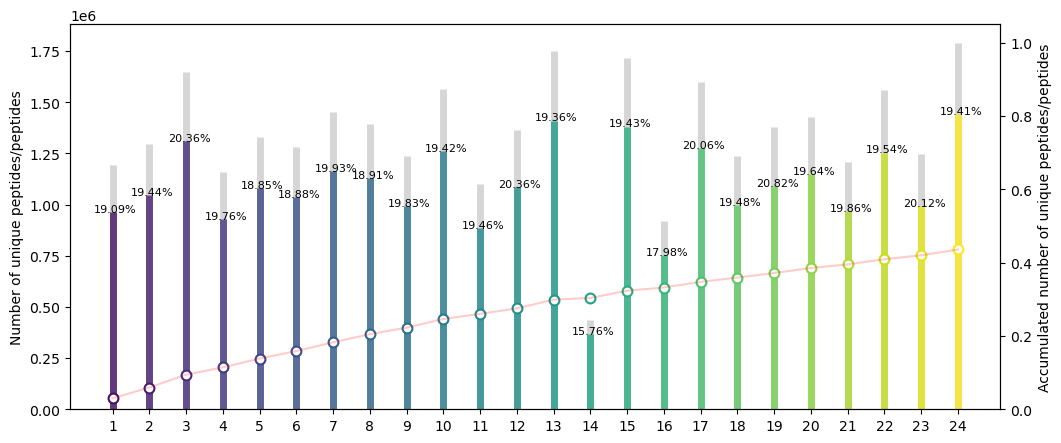

In [157]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))  # 设置图大小
ax = plt.gca()  # 获取当前坐标轴

cmap = plt.cm.viridis
# 计算归一化的颜色值（基于小提琴的位置）
colors = [cmap(i/len(infos2)) for i in range(1,len(infos2)+1)]

# infos2_local = list()
# for cumm_total, cumm_unique in infos2:
#     infos2_local.append([cumm_total/infos2[-1][0], cumm_unique/infos2[-1][0]])
for i, (total, unique) in enumerate(infos1):
    ax.vlines(
        x=i+1,  # 连线的y轴位置（对应每个类别）
        ymin=0,  # 连线左端x值（第一组数据）
        ymax=total,  # 连线右端x值（第二组数据）
        color="#cccccc",  # 连线颜色（灰色，避免抢焦点）
        linewidth=5,  # 连线粗细
        alpha=0.8  # 透明度
    )
    ax.vlines(
        x=i+1,  # 连线的y轴位置（对应每个类别）
        ymin=0,  # 连线左端x值（第一组数据）
        ymax=unique,  # 连线右端x值（第二组数据）
        color=colors[i],  # 连线颜色（灰色，避免抢焦点）
        linewidth=5,  # 连线粗细
        alpha=0.8  # 透明度
    )
    ax.text(i+0.5, unique, f"{(1-unique/total)*100:.2f}%", fontsize=8)

infos2_local = list()
for cumm_total, cumm_unique in infos2:
    infos2_local.append([cumm_total/infos2[-1][0], cumm_unique/infos2[-1][0]])
ax2 = ax.twinx()
for i, (cumm_total, cumm_unique) in enumerate(infos2_local):
    ax2.scatter(
        i+1, cumm_unique,
        color="white",
        # color=colors[3],  # 红色：区分第一组
        s=50,  # 点的大小
        marker="o",  # 圆形标记
        edgecolor=colors[i],  # 白色边框：让点更清晰
        linewidth=1.5
    )
ax2.plot(
    range(1,25), [cumm_unique for _,cumm_unique in infos2_local],
    color="red",
    # s=50,  # 点的大小
    # marker="o",  # 圆形标记
    # edgecolor=colors[len(infos2_local)-i-1],  # 白色边框：让点更清晰
    alpha=0.2,
    linewidth=1.5
)

ax2.set_ylim([0,1.05])
ax.set_ylim(0)
ax2.set_ylabel("Accumulated number of unique peptides/peptides")
ax.set_ylabel("Number of unique peptides/peptides")
ax.set_xticks(list(range(1,25)))
plt.show()

In [159]:
print(sum([b for a,b in infos1])/sum([a for a,b in infos1]))
print(infos2[-1][1]/infos2[-1][0])

0.8045952624326183
0.43585975643369496


In [151]:
print(sum([b for a,b in infos1])/sum([a for a,b in infos1]))
print(infos2[-1][1]/infos2[-1][0])

0.8114775480698982
0.5644161808339249
